In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import numpy as np
import seaborn as sns
from pyboat import WAnalyzer, ssg
from scipy.stats import shapiro, levene, f_oneway, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scikit_posthocs as sp
import warnings
import itertools

In [6]:
base_path1 = r"/Users/katharinasonnen/Library/CloudStorage/OneDrive-HubrechtInstitute/data/RSPO/Axin-LGR5-ECD/LGR-ECD/Axin-stripe quantification/Axin-stripe-quantification.xlsx"

#import data
df = pd.read_excel(base_path1)
display(df)



,Condition,Position,Stripe,PSM,Stripe/PSM,Experiment
0,control,L1,1893.792,1488.899,1.271941,5
1,control,L2,3412.881,2113.492,1.614807,5
2,control,L10,2481.380,1592.356,1.558307,5
3,RSPO3,L11,933.198,900.205,1.036651,5
4,RSPO3,L12,1791.224,1462.600,1.224685,5
5,RSPO3,L3,1019.234,744.155,1.369653,5
6,RSPO3,L4,1015.005,860.803,1.179137,5
7,control,L8,1937.726,1315.921,1.472525,5
8,control,L14,1922.362,1290.783,1.489299,5
9,control,L7,1848.231,1305.936,1.415254,5


/var/folders/jz/gfj_b5gj1yx0lfb2z6dyr1200000gp/T/ipykernel_59318/2714603769.py:44: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(x='Condition', y='Stripe/PSM', data=plot_df,
INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 44 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'C', 'D', 'E', 'G', 'L', 'M', 'O', 'P', 'R', 'S', 'a', 'asterisk', 'c', 'd', 'e', 'eight', 'five', 'four', 'hyphen', 'i', '

Normality per group: [np.True_, np.True_, np.True_]
Equal variances (Levene p=0.5576): True
Using ANOVA
ANOVA p = 0.0061
Significant: running Tukey


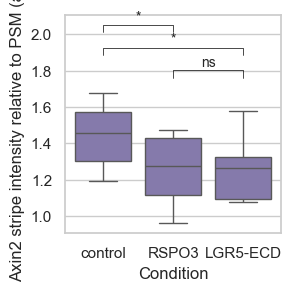

In [10]:
#Plot period


plot_df = df


# --- STATISTICS ---
groups = plot_df['Condition'].unique()
group_data = [plot_df[plot_df['Condition'] == g]['Stripe/PSM'] for g in groups]

# Normality
normality = [shapiro(g)[1] > 0.05 for g in group_data]
print("Normality per group:", normality)

# Equal variances
levene_p = levene(*group_data)[1]
equal_var = levene_p > 0.05
print(f"Equal variances (Levene p={levene_p:.4f}): {equal_var}")

# Overall test
if all(normality) and equal_var:
    print("Using ANOVA")
    overall_p = f_oneway(*group_data)[1]
    print(f"ANOVA p = {overall_p:.4f}")
    if overall_p < 0.05:
        print("Significant: running Tukey")
        tukey = pairwise_tukeyhsd(endog=plot_df['Stripe/PSM'], groups=plot_df['Condition'], alpha=0.05)
        pvalues = {(a, b): tukey.pvalues[i]
                   for i, (a, b) in enumerate(itertools.combinations(tukey.groupsunique, 2))}
else:
    print("Using Kruskal-Wallis")
    overall_p = kruskal(*group_data)[1]
    print(f"Kruskal-Wallis p = {overall_p:.4f}")
    if overall_p < 0.05:
        print("Significant: running Dunn's test")
        dunn = sp.posthoc_dunn(plot_df, val_col='Stripe/PSM', group_col='Condition', p_adjust='bonferroni')
        pvalues = {(a, b): dunn.loc[a, b] for a, b in itertools.combinations(groups, 2)}

# --- PLOTTING ---
sns.set(style="whitegrid")
plt.figure(figsize=(3, 3))

ax = sns.boxplot(x='Condition', y='Stripe/PSM', data=plot_df, color='m', showfliers=False)
sns.stripplot(x='Condition', y='Stripe/PSM', data=plot_df,
              ax=ax, facecolor='none', linewidth=0.5, edgecolor='gray', size=4)

plt.ylabel('Axin2 stripe intensity relative to PSM (a.u.)', fontsize=12)

# Significance annotations
xticks = {label: idx for idx, label in enumerate(plot_df['Condition'].unique())}
y_max = plot_df['Stripe/PSM'].max()

def significance_label(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'

height_step = y_max * 0.05
height = y_max + height_step

for (g1, g2), p in pvalues.items():
    x1, x2 = xticks[g1], xticks[g2]
    y = height
    ax.plot([x1, x1, x2, x2], [y, y + height_step/2, y + height_step/2, y],
            lw=0.5, color='black')
    if overall_p < 0.05:
        label = significance_label(p)
    else:
        label = "ns"
    ax.text((x1 + x2) / 2, y + height_step * 0.6, label,
            ha='center', va='bottom', fontsize=10)
    height += height_step * 1.5


plt.rcParams.update({
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'font.size': 12,
    'font.family': 'Arial'
})
sns.set_context('paper')

plt.tight_layout()
plt.savefig("/Users/katharinasonnen/Library/CloudStorage/OneDrive-HubrechtInstitute/data/RSPO/Axin-LGR5-ECD/LGR-ECD/Axin-stripe quantification/boxplot_editable_period.pdf",
            format='pdf', transparent=True, dpi=600)

plt.show()
